# ANALISIS SENTIMEN DAN DETEKSI ANOMALI ULASAN STEAM MOBILE
## Versi Run All Cepat — Lexicon-Based + Stemming

Notebook ini **tidak melakukan scraping ulang**. Data langsung dibaca dari `steam_reviews_clean.csv` yang sudah tersedia.

Alur yang digunakan:

**load dataset bersih → hapus `polarity` lama → pemisahan Bahasa Inggris/Indonesia → lexicon-based labeling dari isi review → preprocessing + stemming → filtering → balancing → split 80:20 → TF-IDF → Multinomial Naive Bayes → evaluation → deteksi anomali**

Ketentuan utama:
- Rating **tidak digunakan** untuk membuat label target.
- Bahasa Inggris menggunakan **VADER**.
- Bahasa Indonesia menggunakan **InSet**.
- Stemming Inggris menggunakan **Snowball Stemmer**.
- Stemming Indonesia menggunakan **Sastrawi**.
- Rating baru dipetakan menjadi kelas sentimen pada tahap deteksi anomali untuk dibandingkan dengan hasil prediksi model.


In [1]:
%pip install Sastrawi tqdm -q

from pathlib import Path
import re
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.stem import SnowballStemmer

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings("ignore")

nltk.download("stopwords", quiet=True)
nltk.download("vader_lexicon", quiet=True)

tqdm.pandas()

print("✅ Semua library siap.")



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
✅ Semua library siap.


## 1. Load Dataset Bersih

Cell berikut mencari `steam_reviews_clean.csv` di folder notebook saat ini dan di folder project utama. Kolom `polarity` lama dihapus dari memori karena label tersebut sebelumnya berasal dari rating. File CSV asli tidak diubah.


In [2]:
# Cari file dataset bersih
candidates = [
    Path.cwd() / "steam_reviews_clean.csv",
    Path("/Users/mariocristian/Documents/Pi Mario Cristian S/steam_reviews_clean.csv")
]

DATA_PATH = next((p for p in candidates if p.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "steam_reviews_clean.csv tidak ditemukan. "
        "Pastikan file ada di folder project 'Pi Mario Cristian S'."
    )

OUTPUT_DIR = DATA_PATH.parent

df = pd.read_csv(DATA_PATH)

# Rapikan tipe data
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")

# Hapus data yang tidak valid
required_cols = ["negara", "review_id", "review", "rating", "date", "bahasa"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Kolom wajib tidak ditemukan: {missing}")

df = df.dropna(subset=["review", "rating", "date", "bahasa"]).copy()
df = df[df["review"].astype(str).str.strip() != ""].copy()
df = df.drop_duplicates(subset=["review_id"], keep="first").reset_index(drop=True)
df["rating"] = df["rating"].astype(int)
df["bahasa"] = df["bahasa"].astype(str).str.lower().str.strip()

# Hapus label lama dari memori
if "polarity" in df.columns:
    df = df.drop(columns=["polarity"])

print("✅ Dataset berhasil dimuat.")
print(f"Lokasi dataset : {DATA_PATH}")
print(f"Total data     : {len(df):,}")
print("Kolom          :", df.columns.tolist())
display(df.head())


✅ Dataset berhasil dimuat.
Lokasi dataset : /Users/mariocristian/Documents/Pi Mario Cristian S/steam_reviews_clean.csv
Total data     : 300,587
Kolom          : ['negara', 'review_id', 'review', 'rating', 'date', 'bahasa']


,negara,review_id,review,rating,date,bahasa
0,Amerika Serikat,ee288f0f-d9bc-4d1b-898e-2466d58e7547,fr never expected steam's user care to be fast...,5,2026-08-23 03:43:03,en
1,Amerika Serikat,b52736ee-27a9-412f-9ab5-d39222188f28,Steam needs to make game creators declare AI u...,1,2026-08-23 03:37:04,en
2,Amerika Serikat,cc33596b-19a4-44f9-8fcc-1bab8d5f6a2b,thank gaben,5,2026-08-23 03:27:25,en
3,Amerika Serikat,f09a8de8-9cf1-4874-9599-3ac62a104a1e,"can't scan qr codes on GrapheneOS, that includ...",1,2026-08-23 00:36:22,en
4,Amerika Serikat,70e47bf5-781a-44ce-82a0-c31c5dbd3b1b,So peak,5,2026-08-23 00:30:38,id


## 2. Ringkasan Data Understanding

In [3]:
# 10 negara dengan jumlah ulasan terbanyak
top10_negara = (
    df.groupby("negara")
      .size()
      .reset_index(name="total_review")
      .sort_values("total_review", ascending=False)
      .head(10)
      .reset_index(drop=True)
)

print("10 Negara dengan Ulasan Terbanyak:")
display(top10_negara)

top10_negara.to_csv(
    OUTPUT_DIR / "top10_negara_lexicon_final.csv",
    index=False,
    encoding="utf-8"
)


10 Negara dengan Ulasan Terbanyak:


,negara,total_review
0,Amerika Serikat,81953
1,Rusia,70838
2,Meksiko,28129
3,Brasil,22367
4,Turki,12308
5,Polandia,12164
6,Jerman,10770
7,Indonesia,7544
8,Haiti,6253
9,Korea Selatan,5870


In [4]:
# Pemisahan awal berdasarkan bahasa
df_en = df[df["bahasa"] == "en"].copy()
df_id = df[df["bahasa"] == "id"].copy()

print(f"Total Bahasa Inggris   : {len(df_en):,}")
print(f"Total Bahasa Indonesia : {len(df_id):,}")


Total Bahasa Inggris   : 84,115
Total Bahasa Indonesia : 6,096


## 3. Persiapan Lexicon

Bahasa Inggris dan Bahasa Indonesia menggunakan lexicon yang berbeda:
- **VADER** untuk ulasan Bahasa Inggris.
- **InSet** untuk ulasan Bahasa Indonesia.

Pelabelan dilakukan dari **isi review**, bukan dari rating.


In [5]:
# VADER — Bahasa Inggris
vader = SentimentIntensityAnalyzer()

def clean_for_vader(text):
    text = str(text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def vader_score(text):
    return vader.polarity_scores(clean_for_vader(text))["compound"]

def vader_label(score):
    if score >= 0.05:
        return "positif"
    elif score <= -0.05:
        return "negatif"
    return "netral"

print("✅ VADER Bahasa Inggris siap.")


✅ VADER Bahasa Inggris siap.


In [6]:
# InSet — Bahasa Indonesia
INSET_POS_URL = "https://raw.githubusercontent.com/fajri91/InSet/master/positive.tsv"
INSET_NEG_URL = "https://raw.githubusercontent.com/fajri91/InSet/master/negative.tsv"

def load_inset(url):
    temp = pd.read_csv(
        url,
        sep="\t",
        header=None,
        names=["word", "weight"],
        dtype=str
    )
    temp["word"] = temp["word"].astype(str).str.lower().str.strip()
    temp["weight"] = pd.to_numeric(temp["weight"], errors="coerce")
    temp = temp.dropna(subset=["word", "weight"])
    return temp

inset_pos = load_inset(INSET_POS_URL)
inset_neg = load_inset(INSET_NEG_URL)

inset_all = pd.concat([inset_pos, inset_neg], ignore_index=True)

# Jika kata yang sama muncul lebih dari sekali, bobotnya dijumlahkan.
inset_lexicon = (
    inset_all.groupby("word")["weight"]
             .sum()
             .to_dict()
)

print(f"Jumlah lexicon positif Indonesia : {len(inset_pos):,}")
print(f"Jumlah lexicon negatif Indonesia : {len(inset_neg):,}")
print(f"Total kata/frasa unik InSet      : {len(inset_lexicon):,}")
print("✅ InSet Bahasa Indonesia siap.")


Jumlah lexicon positif Indonesia : 3,609
Jumlah lexicon negatif Indonesia : 6,609
Total kata/frasa unik InSet      : 9,071
✅ InSet Bahasa Indonesia siap.


## 4. Lexicon-Based Labeling

In [7]:
# LABELING BAHASA INGGRIS — VADER
print("Memproses labeling VADER Bahasa Inggris...")

df_en["lexicon_score"] = df_en["review"].progress_apply(vader_score)
df_en["polarity"] = df_en["lexicon_score"].apply(vader_label)

print("\n✅ Labeling Bahasa Inggris selesai.")
print(df_en["polarity"].value_counts())


Memproses labeling VADER Bahasa Inggris...


  0%|          | 0/84115 [00:00<?, ?it/s]


✅ Labeling Bahasa Inggris selesai.
polarity
positif    38887
negatif    24225
netral     21003
Name: count, dtype: int64


In [8]:
# LABELING BAHASA INDONESIA — InSet
def clean_for_inset(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#", " ", text)
    text = re.sub(r"[^a-zA-Z\s-]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def inset_score(text):
    # Pencocokan frasa terpanjang 4 -> 3 -> 2 -> 1 token.
    tokens = clean_for_inset(text).split()
    score = 0.0
    i = 0

    while i < len(tokens):
        found = False

        for n in (4, 3, 2, 1):
            if i + n > len(tokens):
                continue

            phrase = " ".join(tokens[i:i+n])

            if phrase in inset_lexicon:
                score += float(inset_lexicon[phrase])
                i += n
                found = True
                break

        if not found:
            i += 1

    return score

def inset_label(score):
    if score > 0:
        return "positif"
    elif score < 0:
        return "negatif"
    return "netral"

print("Memproses labeling InSet Bahasa Indonesia...")

df_id["lexicon_score"] = df_id["review"].progress_apply(inset_score)
df_id["polarity"] = df_id["lexicon_score"].apply(inset_label)

print("\n✅ Labeling Bahasa Indonesia selesai.")
print(df_id["polarity"].value_counts())


Memproses labeling InSet Bahasa Indonesia...


  0%|          | 0/6096 [00:00<?, ?it/s]


✅ Labeling Bahasa Indonesia selesai.
polarity
negatif    2975
positif    1723
netral     1398
Name: count, dtype: int64


In [9]:
print("=" * 55)
print("DISTRIBUSI LABEL LEXICON-BASED")
print("=" * 55)

ringkasan_label = pd.DataFrame({
    "Bahasa Inggris": df_en["polarity"].value_counts(),
    "Bahasa Indonesia": df_id["polarity"].value_counts()
}).fillna(0).astype(int)

display(ringkasan_label)

ringkasan_label.to_csv(
    OUTPUT_DIR / "distribusi_label_lexicon_final.csv",
    encoding="utf-8"
)


DISTRIBUSI LABEL LEXICON-BASED


,Bahasa Inggris,Bahasa Indonesia
polarity,,
negatif,24225,2975
netral,21003,1398
positif,38887,1723


## 5. Preprocessing dan Stemming

Preprocessing dilakukan **setelah label sentimen diperoleh**.

- Bahasa Inggris: case folding, cleaning, stopword removal, **Snowball Stemmer**.
- Bahasa Indonesia: case folding, cleaning, stopword removal, **Sastrawi Stemmer**.

Kata negasi utama dipertahankan.


In [10]:
stop_en = set(stopwords.words("english")) - {"no", "nor", "not"}
stop_id = set(stopwords.words("indonesian")) - {
    "tidak", "tak", "bukan", "belum", "jangan",
    "gak", "ga", "nggak", "enggak"
}

stemmer_en = SnowballStemmer("english")
stemmer_id = StemmerFactory().create_stemmer()

def preprocess_english(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"[^a-zA-Z\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = [
        token for token in text.split()
        if token not in stop_en and len(token) > 1
    ]

    return " ".join(stemmer_en.stem(token) for token in tokens)

def preprocess_indonesian(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = [
        token for token in text.split()
        if token not in stop_id and len(token) > 1
    ]

    if not tokens:
        return ""

    return stemmer_id.stem(" ".join(tokens))

print("Memproses stemming Bahasa Inggris...")
df_en["text_final"] = df_en["review"].progress_apply(preprocess_english)

print("\nMemproses stemming Bahasa Indonesia...")
df_id["text_final"] = df_id["review"].progress_apply(preprocess_indonesian)

print("\n✅ Preprocessing dan stemming selesai.")


Memproses stemming Bahasa Inggris...


  0%|          | 0/84115 [00:00<?, ?it/s]


Memproses stemming Bahasa Indonesia...


  0%|          | 0/6096 [00:00<?, ?it/s]


✅ Preprocessing dan stemming selesai.


## 6. Filtering Dataset Model

In [11]:
df_model_en = (
    df_en[df_en["text_final"].fillna("").str.strip() != ""]
    .copy()
    .reset_index(drop=True)
)

df_model_id = (
    df_id[df_id["text_final"].fillna("").str.strip() != ""]
    .copy()
    .reset_index(drop=True)
)

print(f"Data model Bahasa Inggris   : {len(df_model_en):,}")
print(f"Data model Bahasa Indonesia : {len(df_model_id):,}")

print("\nDistribusi English:")
print(df_model_en["polarity"].value_counts())

print("\nDistribusi Indonesia:")
print(df_model_id["polarity"].value_counts())


Data model Bahasa Inggris   : 84,011
Data model Bahasa Indonesia : 6,067

Distribusi English:
polarity
positif    38887
negatif    24224
netral     20900
Name: count, dtype: int64

Distribusi Indonesia:
polarity
negatif    2968
positif    1719
netral     1380
Name: count, dtype: int64


## 7. Balancing Sebelum Split

Balancing dilakukan secara terpisah untuk masing-masing bahasa sebelum pembagian data 80:20.


In [12]:
def balance_three_classes(data, label_col="polarity", random_state=42):
    groups = {
        label: data[data[label_col] == label]
        for label in ["negatif", "netral", "positif"]
    }

    if any(len(g) == 0 for g in groups.values()):
        kosong = [k for k, g in groups.items() if len(g) == 0]
        raise ValueError(f"Kelas kosong ditemukan: {kosong}")

    # Target menggunakan jumlah minimum agar tidak memperbesar dataset secara berlebihan.
    target = min(len(g) for g in groups.values())

    balanced = []

    for label, group in groups.items():
        balanced.append(
            resample(
                group,
                replace=False,
                n_samples=target,
                random_state=random_state
            )
        )

    return (
        pd.concat(balanced)
          .sample(frac=1, random_state=random_state)
          .reset_index(drop=True)
    )

print("Distribusi SEBELUM balancing — English:")
print(df_model_en["polarity"].value_counts())

df_bal_en = balance_three_classes(df_model_en)

print("\nDistribusi SETELAH balancing — English:")
print(df_bal_en["polarity"].value_counts())

print("\nDistribusi SEBELUM balancing — Indonesia:")
print(df_model_id["polarity"].value_counts())

df_bal_id = balance_three_classes(df_model_id)

print("\nDistribusi SETELAH balancing — Indonesia:")
print(df_bal_id["polarity"].value_counts())

print(f"\nTotal balanced English   : {len(df_bal_en):,}")
print(f"Total balanced Indonesia : {len(df_bal_id):,}")


Distribusi SEBELUM balancing — English:
polarity
positif    38887
negatif    24224
netral     20900
Name: count, dtype: int64

Distribusi SETELAH balancing — English:
polarity
netral     20900
negatif    20900
positif    20900
Name: count, dtype: int64

Distribusi SEBELUM balancing — Indonesia:
polarity
negatif    2968
positif    1719
netral     1380
Name: count, dtype: int64

Distribusi SETELAH balancing — Indonesia:
polarity
positif    1380
netral     1380
negatif    1380
Name: count, dtype: int64

Total balanced English   : 62,700
Total balanced Indonesia : 4,140


## 8. Split 80:20

In [13]:
X_train_en_raw, X_test_en_raw, y_train_en, y_test_en = train_test_split(
    df_bal_en["text_final"],
    df_bal_en["polarity"],
    test_size=0.2,
    random_state=42,
    stratify=df_bal_en["polarity"]
)

X_train_id_raw, X_test_id_raw, y_train_id, y_test_id = train_test_split(
    df_bal_id["text_final"],
    df_bal_id["polarity"],
    test_size=0.2,
    random_state=42,
    stratify=df_bal_id["polarity"]
)

print(f"English   — train: {len(X_train_en_raw):,} | test: {len(X_test_en_raw):,}")
print(f"Indonesia — train: {len(X_train_id_raw):,} | test: {len(X_test_id_raw):,}")

print("\nDistribusi test English:")
print(y_test_en.value_counts())

print("\nDistribusi test Indonesia:")
print(y_test_id.value_counts())


English   — train: 50,160 | test: 12,540
Indonesia — train: 3,312 | test: 828

Distribusi test English:
polarity
negatif    4180
positif    4180
netral     4180
Name: count, dtype: int64

Distribusi test Indonesia:
polarity
negatif    276
netral     276
positif    276
Name: count, dtype: int64


## 9. TF-IDF

In [14]:
tfidf_en = TfidfVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.9,
    ngram_range=(1, 2),
    sublinear_tf=True
)

tfidf_id = TfidfVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.9,
    ngram_range=(1, 2),
    sublinear_tf=True
)

X_train_en = tfidf_en.fit_transform(X_train_en_raw)
X_test_en = tfidf_en.transform(X_test_en_raw)

X_train_id = tfidf_id.fit_transform(X_train_id_raw)
X_test_id = tfidf_id.transform(X_test_id_raw)

print("TF-IDF English:")
print("Train:", X_train_en.shape, "| Test:", X_test_en.shape)

print("\nTF-IDF Indonesia:")
print("Train:", X_train_id.shape, "| Test:", X_test_id.shape)


TF-IDF English:
Train: (50160, 5000) | Test: (12540, 5000)

TF-IDF Indonesia:
Train: (3312, 2822) | Test: (828, 2822)


## 10. Multinomial Naive Bayes

In [15]:
model_nb_en = MultinomialNB(alpha=0.5)
model_nb_id = MultinomialNB(alpha=0.5)

model_nb_en.fit(X_train_en, y_train_en)
model_nb_id.fit(X_train_id, y_train_id)

y_pred_en = model_nb_en.predict(X_test_en)
y_pred_id = model_nb_id.predict(X_test_id)

print("✅ Kedua model berhasil dilatih.")


✅ Kedua model berhasil dilatih.


## 11. Evaluation

In [16]:
labels_order = ["negatif", "netral", "positif"]

accuracy_en = accuracy_score(y_test_en, y_pred_en)
accuracy_id = accuracy_score(y_test_id, y_pred_id)

print(f"Accuracy Bahasa Inggris   : {accuracy_en:.4f} ({accuracy_en*100:.2f}%)")
print(f"Accuracy Bahasa Indonesia : {accuracy_id:.4f} ({accuracy_id*100:.2f}%)")

print("\nCLASSIFICATION REPORT — ENGLISH")
print(
    classification_report(
        y_test_en,
        y_pred_en,
        labels=labels_order,
        zero_division=0
    )
)

print("\nCLASSIFICATION REPORT — INDONESIA")
print(
    classification_report(
        y_test_id,
        y_pred_id,
        labels=labels_order,
        zero_division=0
    )
)

report_en = pd.DataFrame(
    classification_report(
        y_test_en,
        y_pred_en,
        labels=labels_order,
        output_dict=True,
        zero_division=0
    )
).T

report_id = pd.DataFrame(
    classification_report(
        y_test_id,
        y_pred_id,
        labels=labels_order,
        output_dict=True,
        zero_division=0
    )
).T

report_en.to_csv(OUTPUT_DIR / "classification_report_en_final.csv")
report_id.to_csv(OUTPUT_DIR / "classification_report_id_final.csv")


Accuracy Bahasa Inggris   : 0.7432 (74.32%)
Accuracy Bahasa Indonesia : 0.6848 (68.48%)

CLASSIFICATION REPORT — ENGLISH
              precision    recall  f1-score   support

     negatif       0.71      0.77      0.74      4180
      netral       0.80      0.68      0.74      4180
     positif       0.74      0.77      0.75      4180

    accuracy                           0.74     12540
   macro avg       0.75      0.74      0.74     12540
weighted avg       0.75      0.74      0.74     12540


CLASSIFICATION REPORT — INDONESIA
              precision    recall  f1-score   support

     negatif       0.56      0.91      0.70       276
      netral       0.82      0.50      0.62       276
     positif       0.83      0.65      0.73       276

    accuracy                           0.68       828
   macro avg       0.74      0.68      0.68       828
weighted avg       0.74      0.68      0.68       828



Confusion Matrix English:
[[3231  293  656]
 [ 631 2861  688]
 [ 526  426 3228]]


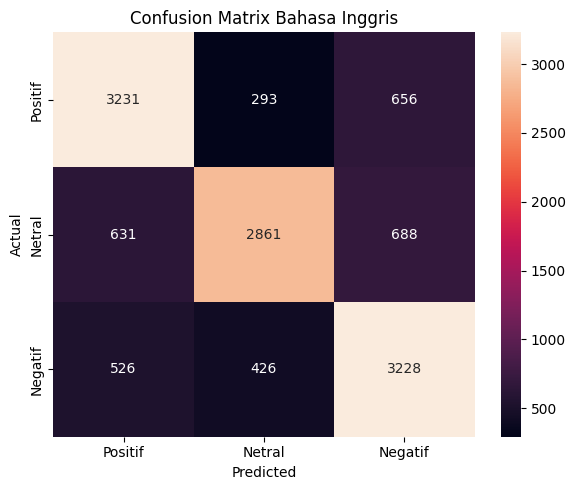


Confusion Matrix Indonesia:
[[179  21  76]
 [ 21 138 117]
 [ 16  10 250]]


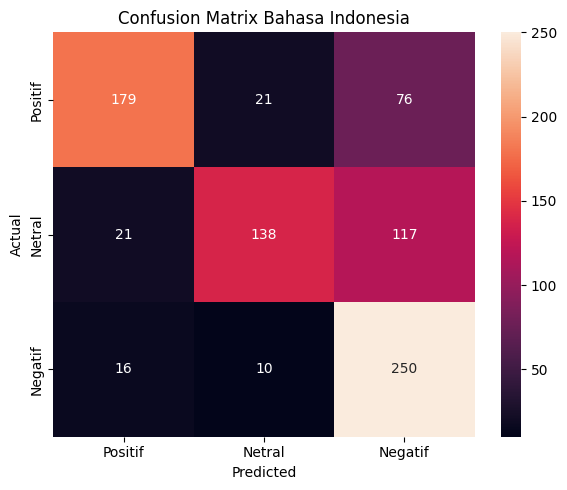

In [17]:
cm_labels = ["positif", "netral", "negatif"]

cm_en = confusion_matrix(y_test_en, y_pred_en, labels=cm_labels)
cm_id = confusion_matrix(y_test_id, y_pred_id, labels=cm_labels)

print("Confusion Matrix English:")
print(cm_en)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_en,
    annot=True,
    fmt="d",
    xticklabels=["Positif", "Netral", "Negatif"],
    yticklabels=["Positif", "Netral", "Negatif"]
)
plt.title("Confusion Matrix Bahasa Inggris")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

print("\nConfusion Matrix Indonesia:")
print(cm_id)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_id,
    annot=True,
    fmt="d",
    xticklabels=["Positif", "Netral", "Negatif"],
    yticklabels=["Positif", "Netral", "Negatif"]
)
plt.title("Confusion Matrix Bahasa Indonesia")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


## 12. Deteksi Anomali

Rating hanya digunakan pada tahap ini. Rating dipetakan ke tiga kelas agar dapat dibandingkan dengan sentimen hasil prediksi model.


In [18]:
def rating_to_sentiment(rating):
    if rating >= 4:
        return "positif"
    elif rating == 3:
        return "netral"
    return "negatif"

# ENGLISH
df_model_en["rating_sentiment"] = df_model_en["rating"].apply(rating_to_sentiment)
df_model_en["sentiment_model"] = model_nb_en.predict(
    tfidf_en.transform(df_model_en["text_final"])
)
df_model_en["anomaly_status"] = np.where(
    df_model_en["rating_sentiment"] == df_model_en["sentiment_model"],
    "normal",
    "anomali"
)

# INDONESIA
df_model_id["rating_sentiment"] = df_model_id["rating"].apply(rating_to_sentiment)
df_model_id["sentiment_model"] = model_nb_id.predict(
    tfidf_id.transform(df_model_id["text_final"])
)
df_model_id["anomaly_status"] = np.where(
    df_model_id["rating_sentiment"] == df_model_id["sentiment_model"],
    "normal",
    "anomali"
)

print("Distribusi Anomali — English")
print(df_model_en["anomaly_status"].value_counts())

print("\nDistribusi Anomali — Indonesia")
print(df_model_id["anomaly_status"].value_counts())


Distribusi Anomali — English
anomaly_status
normal     49311
anomali    34700
Name: count, dtype: int64

Distribusi Anomali — Indonesia
anomaly_status
normal     3291
anomali    2776
Name: count, dtype: int64


## 13. Ringkasan Hasil dan Penyimpanan

In [19]:
summary = pd.DataFrame([
    {
        "bahasa": "English",
        "jumlah_data_model": len(df_model_en),
        "accuracy": accuracy_en,
        "normal": int((df_model_en["anomaly_status"] == "normal").sum()),
        "anomali": int((df_model_en["anomaly_status"] == "anomali").sum())
    },
    {
        "bahasa": "Indonesia",
        "jumlah_data_model": len(df_model_id),
        "accuracy": accuracy_id,
        "normal": int((df_model_id["anomaly_status"] == "normal").sum()),
        "anomali": int((df_model_id["anomaly_status"] == "anomali").sum())
    }
])

summary["persentase_anomali"] = (
    summary["anomali"] / summary["jumlah_data_model"] * 100
).round(2)

display(summary)

# Simpan hasil final di folder dataset/project
df_model_en.to_csv(
    OUTPUT_DIR / "steam_reviews_model_result_en_LEXICON_FINAL.csv",
    index=False,
    encoding="utf-8"
)

df_model_id.to_csv(
    OUTPUT_DIR / "steam_reviews_model_result_id_LEXICON_FINAL.csv",
    index=False,
    encoding="utf-8"
)

summary.to_csv(
    OUTPUT_DIR / "ringkasan_hasil_lexicon_final.csv",
    index=False,
    encoding="utf-8"
)

print("\n✅ SEMUA PROSES SELESAI.")
print(f"Semua file hasil disimpan di: {OUTPUT_DIR}")
print("\nFile penting:")
print("- steam_reviews_model_result_en_LEXICON_FINAL.csv")
print("- steam_reviews_model_result_id_LEXICON_FINAL.csv")
print("- ringkasan_hasil_lexicon_final.csv")
print("- classification_report_en_final.csv")
print("- classification_report_id_final.csv")


,bahasa,jumlah_data_model,accuracy,normal,anomali,persentase_anomali
0,English,84011,0.743222,49311,34700,41.30
1,Indonesia,6067,0.684783,3291,2776,45.76



✅ SEMUA PROSES SELESAI.
Semua file hasil disimpan di: /Users/mariocristian/Documents/Pi Mario Cristian S

File penting:
- steam_reviews_model_result_en_LEXICON_FINAL.csv
- steam_reviews_model_result_id_LEXICON_FINAL.csv
- ringkasan_hasil_lexicon_final.csv
- classification_report_en_final.csv
- classification_report_id_final.csv


## Catatan untuk Penulisan Ilmiah

Gunakan output notebook ini sebagai dasar pembaruan BAB 3, abstrak, kesimpulan, dan PPT.

**Jangan menggunakan kembali angka hasil lama yang berasal dari pelabelan berbasis rating.**
